# Análise de Dados — Copa do Mundo 2022

Investigação dos fatores que mais influenciam o resultado de uma partida de futebol,
com base nos dados oficiais da Copa do Mundo FIFA 2022.

A análise é estruturada em três dimensões:

1. **Posse de bola** — domínio territorial via posse;
2. **Eficiência ofensiva** — capacidade de converter finalizações em gols;
3. **Construção de jogadas** — progressão e quebra de linhas adversárias.

A hipótese central é avaliar criticamente a noção popular de que maior posse de bola
implica maior probabilidade de vitória.

## 1. Importação de bibliotecas

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

## 1.1 Configuração do diretório de trabalho

Para garantir que os caminhos relativos funcionem independentemente de onde
o notebook é aberto (raiz do projeto ou pasta `notebooks/`), o diretório de
trabalho é normalizado para a raiz do projeto.

In [29]:
import os
from pathlib import Path

# Se o notebook foi aberto a partir de notebooks/, sobe um nível
if Path.cwd().name == 'notebooks':
    os.chdir('..')

print('Diretório de trabalho:', Path.cwd())

Diretório de trabalho: c:\Users\eduar\OneDrive\Área de Trabalho\world-cup-2022-analysis


## 2. Carregamento dos dados brutos

O dataset original contém uma linha por partida, com métricas separadas por sufixo
`team1` e `team2`. Esse formato é inadequado para análise estatística por time,
o que motiva a reestruturação aplicada nas etapas seguintes.

In [30]:
def carregar_dados_brutos(caminho: str) -> pd.DataFrame:
    """Carrega o dataset bruto da Copa do Mundo 2022 a partir de um arquivo CSV.

    Args:
        caminho: Caminho relativo ou absoluto para o arquivo CSV de origem.

    Returns:
        DataFrame contendo todas as colunas originais do dataset, sem
        qualquer transformação aplicada.
    """
    return pd.read_csv(caminho)


df = carregar_dados_brutos('data/raw/Fifa_world_cup_matches.csv')
df.head()

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42%,50%,8%,0,2,20 NOV 2022,17 : 00,Group A,...,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,...,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21 NOV 2022,17 : 00,Group A,...,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51%,39%,10%,1,1,21 NOV 2022,20 : 00,Group B,...,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22 NOV 2022,11 : 00,Group C,...,1,0,4,14,0,0,65,80,163,361


## 3. Seleção de colunas relevantes

Do total de colunas disponíveis no dataset original, apenas um subconjunto é
diretamente relevante para a análise das três dimensões definidas. As demais
colunas (faltas, dados de goleiros, escanteios etc.) são descartadas para
reduzir ruído e simplificar a etapa de transformação.

Observação técnica: alguns nomes de coluna do dataset original possuem
inconsistências de formatação (espaços duplos, espaço ausente entre palavras).
Esses nomes são preservados aqui exatamente como aparecem no CSV de origem.

In [31]:
COLUNAS_RELEVANTES = [
    # Identificação
    'team1', 'team2',

    # Posse de bola
    'possession team1', 'possession team2',

    # Resultado
    'number of goals team1', 'number of goals team2',

    # Volume ofensivo
    'total attempts team1', 'total attempts team2',
    'on target attempts team1', 'on target attempts team2',

    # Qualidade da chance
    'attempts inside the penalty area team1',
    'attempts inside the penalty area  team2',  # nome original do CSV (espaço duplo)

    # Construção de jogadas
    'receptions between midfield and defensive lines team1',
    'receptions between midfield and defensive lines team2',
    'attempted line breaks team1', 'attempted line breaks team2',
    'completed line breaksteam1',  # nome original do CSV (sem espaço)
    'completed line breaks team2',

    # Distribuição
    'passes completed team1', 'passes completed team2',
    'crosses team1', 'crosses team2',

    # Pressão defensiva
    'forced turnovers team1', 'forced turnovers team2',
    'defensive pressures applied team1', 'defensive pressures applied team2',

    # Indicadores disciplinares
    'red cards team1', 'red cards team2'
]


def filtrar_colunas_relevantes(df: pd.DataFrame, colunas: list) -> pd.DataFrame:
    """Restringe o DataFrame às colunas necessárias para a análise.

    Args:
        df: DataFrame de entrada contendo o dataset completo.
        colunas: Lista de nomes de colunas a serem mantidas.

    Returns:
        Cópia do DataFrame contendo apenas as colunas selecionadas, com
        a coluna ``match_id`` adicionada como identificador único de partida.
    """
    df_filtrado = df[colunas].copy()
    df_filtrado['match_id'] = df_filtrado.index
    return df_filtrado


df_filtrado = filtrar_colunas_relevantes(df, COLUNAS_RELEVANTES)
df_filtrado.head()

,team1,team2,possession team1,possession team2,number of goals team1,number of goals team2,total attempts team1,total attempts team2,on target attempts team1,on target attempts team2,...,passes completed team2,crosses team1,crosses team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2,red cards team1,red cards team2,match_id
0,QATAR,ECUADOR,42%,50%,0,2,5,6,0,3,...,409,9,14,52,72,256,279,0,0,0
1,ENGLAND,IRAN,72%,19%,6,2,13,8,7,3,...,154,23,8,63,72,139,416,0,0,1
2,SENEGAL,NETHERLANDS,44%,45%,0,2,14,9,3,3,...,374,19,25,63,73,263,251,0,0,2
3,UNITED STATES,WALES,51%,39%,1,1,6,7,1,3,...,321,31,15,81,72,242,292,0,0,3
4,ARGENTINA,SAUDI ARABIA,64%,24%,1,2,14,3,6,2,...,190,29,9,65,80,163,361,0,0,4


## 4. Reestruturação para nível de time

Cada partida originalmente ocupa uma única linha com métricas espelhadas para
os dois times. Para que a análise opere no nível de **time-jogo**, a base é
reestruturada de modo que cada partida produza duas observações: uma para o
time mandante (team1) e outra para o adversário (team2).

Essa transformação é equivalente a um *unpivot* parcial e é o passo mais
crítico do pré-processamento, pois habilita comparações diretas entre
vencedores e não vencedores na mesma escala.

In [32]:
COLUNAS_PADRONIZADAS = [
    'match_id', 'team', 'possession', 'goals',
    'total_attempts', 'on_target_attempts', 'attempts_inside_area',
    'final_third_receptions', 'attempted_line_breaks', 'completed_line_breaks',
    'passes_completed', 'crosses', 'forced_turnovers',
    'defensive_pressures', 'red_cards'
]


def extrair_dados_time(df: pd.DataFrame, sufixo: str, mapa_colunas: list) -> pd.DataFrame:
    """Extrai e padroniza as métricas de um dos times de cada partida.

    A função recebe o DataFrame em formato wide (uma linha por partida) e
    retorna um DataFrame em formato long para o time identificado pelo sufixo
    (``team1`` ou ``team2``), com nomes de colunas padronizados.

    Args:
        df: DataFrame com as colunas relevantes da Copa do Mundo 2022.
        sufixo: Sufixo do time a ser extraído. Aceita ``'team1'`` ou ``'team2'``.
        mapa_colunas: Lista de colunas no formato original do CSV referentes
            ao time desejado, na ordem correspondente a ``COLUNAS_PADRONIZADAS``.

    Returns:
        DataFrame com 15 colunas padronizadas, contendo uma linha por partida
        para o time especificado.

    Raises:
        ValueError: Se o sufixo informado não for ``'team1'`` ou ``'team2'``.
    """
    if sufixo not in ('team1', 'team2'):
        raise ValueError("sufixo deve ser 'team1' ou 'team2'")

    df_time = df[mapa_colunas].copy()
    df_time.columns = COLUNAS_PADRONIZADAS
    return df_time


# Mapeamento das colunas originais para o time 1
colunas_team1 = [
    'match_id', 'team1',
    'possession team1', 'number of goals team1',
    'total attempts team1', 'on target attempts team1',
    'attempts inside the penalty area team1',
    'receptions between midfield and defensive lines team1',
    'attempted line breaks team1', 'completed line breaksteam1',
    'passes completed team1', 'crosses team1',
    'forced turnovers team1', 'defensive pressures applied team1',
    'red cards team1'
]

# Mapeamento das colunas originais para o time 2
colunas_team2 = [
    'match_id', 'team2',
    'possession team2', 'number of goals team2',
    'total attempts team2', 'on target attempts team2',
    'attempts inside the penalty area  team2',
    'receptions between midfield and defensive lines team2',
    'attempted line breaks team2', 'completed line breaks team2',
    'passes completed team2', 'crosses team2',
    'forced turnovers team2', 'defensive pressures applied team2',
    'red cards team2'
]

df_team1 = extrair_dados_time(df_filtrado, 'team1', colunas_team1)
df_team2 = extrair_dados_time(df_filtrado, 'team2', colunas_team2)

df_final = pd.concat([df_team1, df_team2], ignore_index=True)
df_final.sort_values('match_id').head(10)

,match_id,team,possession,goals,total_attempts,on_target_attempts,attempts_inside_area,final_third_receptions,attempted_line_breaks,completed_line_breaks,passes_completed,crosses,forced_turnovers,defensive_pressures,red_cards
0,0,QATAR,42%,0,5,0,2,5,136,86,381,9,52,256,0
64,0,ECUADOR,50%,2,6,3,4,8,155,99,409,14,72,279,0
65,1,IRAN,19%,2,8,3,6,4,101,45,154,8,72,416,0
1,1,ENGLAND,72%,6,13,7,10,16,238,178,730,23,63,139,0
2,2,SENEGAL,44%,0,14,3,7,15,151,89,313,19,63,263,0
66,2,NETHERLANDS,45%,2,9,3,5,14,162,96,374,25,73,251,0
67,3,WALES,39%,1,7,3,5,9,174,103,321,15,72,292,0
3,3,UNITED STATES,51%,1,6,1,4,12,199,146,509,31,81,242,0
4,4,ARGENTINA,64%,1,14,6,10,26,191,127,529,29,65,163,0
68,4,SAUDI ARABIA,24%,2,3,2,3,9,137,68,190,9,80,361,0


## 5. Limpeza e conversão de tipos

A coluna `possession` está originalmente armazenada como string com sufixo
percentual (ex.: `"58%"`), o que impede operações numéricas. A conversão para
formato numérico é feita removendo o caractere `%` e aplicando coerção segura.

In [33]:
def converter_posse_para_numerico(df: pd.DataFrame, coluna: str = 'possession') -> pd.DataFrame:
    """Converte a coluna de posse de bola de string percentual para float.

    Trata valores no formato ``"XX%"``, removendo o caractere de porcentagem
    e convertendo para tipo numérico. Valores inválidos são convertidos para
    NaN via ``errors='coerce'``.

    Args:
        df: DataFrame contendo a coluna de posse.
        coluna: Nome da coluna a ser convertida. Padrão: ``'possession'``.

    Returns:
        DataFrame com a coluna convertida para tipo float.
    """
    df = df.copy()
    df[coluna] = (
        df[coluna]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.strip()
    )
    df[coluna] = pd.to_numeric(df[coluna], errors='coerce')
    return df


df_final = converter_posse_para_numerico(df_final)
df_final['possession'].dtype

dtype('int64')

## 6. Engenharia de atributos

Três variáveis derivadas são construídas para sustentar a análise:

- **`efficiency`**: razão entre gols e finalizações no alvo. É uma proxy direta
  da capacidade de conversão. A divisão é tratada para evitar erros quando o
  time não registra finalizações no alvo.
- **`build_up_score`**: soma agregada de três indicadores de progressão ofensiva
  (recepções no terço final, tentativas e quebras de linha completadas).
  Funciona como uma métrica composta de construção.
- **`win`**: variável binária derivada do confronto direto entre os times de
  uma mesma partida. Recebe `1` para o time com maior número de gols na
  partida e `0` para o adversário. Empates resultam em `win=0` para ambos os
  times — premissa documentada e adotada de forma consistente em toda a
  análise.

In [34]:
def calcular_eficiencia(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula a eficiência ofensiva como gols por chute no alvo.

    A divisão por zero é tratada explicitamente: quando o time não registra
    chutes no alvo, a eficiência é definida como zero, evitando geração de
    NaN ou inf no DataFrame resultante.

    Args:
        df: DataFrame com as colunas ``goals`` e ``on_target_attempts``.

    Returns:
        DataFrame com a coluna ``efficiency`` adicionada.
    """
    df = df.copy()
    df['efficiency'] = np.where(
        df['on_target_attempts'] > 0,
        df['goals'] / df['on_target_attempts'],
        0
    )
    return df


def calcular_build_up_score(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula o índice composto de construção ofensiva (build-up).

    O indicador é definido como a soma de três métricas de progressão:
    recepções no terço final do campo, tentativas de quebra de linha
    e quebras de linha efetivamente completadas.

    Args:
        df: DataFrame com as colunas ``final_third_receptions``,
            ``attempted_line_breaks`` e ``completed_line_breaks``.

    Returns:
        DataFrame com a coluna ``build_up_score`` adicionada.
    """
    df = df.copy()
    df['build_up_score'] = (
        df['final_third_receptions']
        + df['attempted_line_breaks']
        + df['completed_line_breaks']
    )
    return df


def criar_variavel_resultado(df: pd.DataFrame) -> pd.DataFrame:
    """Cria a variável binária ``win`` indicando vitória do time na partida.

    A vitória é determinada por confronto direto: para cada ``match_id``,
    o time com o maior número de gols recebe ``win=1``. Em caso de empate,
    ambos os times recebem ``win=0``, equiparando empate a derrota para fins
    de análise.

    Args:
        df: DataFrame com as colunas ``match_id`` e ``goals``.

    Returns:
        DataFrame com as colunas ``max_goals`` e ``win`` adicionadas.
    """
    df = df.copy()
    df['max_goals'] = df.groupby('match_id')['goals'].transform('max')
    df['win'] = (df['goals'] == df['max_goals']).astype(int)
    return df


df_final = calcular_eficiencia(df_final)
df_final = calcular_build_up_score(df_final)
df_final = criar_variavel_resultado(df_final)


def classificar_resultado(df: pd.DataFrame) -> pd.DataFrame:
    """Classifica cada linha como vitória, empate ou derrota.

    Cria a variável categórica ``match_result`` com três classes (``'W'``,
    ``'D'``, ``'L'``), evitando a perda de informação que ocorre quando
    empates são agregados a derrotas em uma variável binária.

    Args:
        df: DataFrame contendo as colunas ``match_id`` e ``goals``.

    Returns:
        DataFrame com a coluna ``match_result`` adicionada.
    """
    df = df.copy()
    gols_por_partida = df.groupby('match_id')['goals'].agg(['max', 'min'])
    gols_por_partida['empate'] = gols_por_partida['max'] == gols_por_partida['min']
    df = df.merge(gols_por_partida[['empate']], on='match_id')

    df['match_result'] = np.where(
        df['empate'], 'D',
        np.where(df['goals'] == df['max_goals'], 'W', 'L')
    )
    df = df.drop(columns=['empate'])
    return df


df_final = classificar_resultado(df_final)
df_final[['match_id', 'team', 'goals', 'win', 'match_result']].head()

,match_id,team,goals,win,match_result
0,0,QATAR,0,0,L
1,1,ENGLAND,6,1,W
2,2,SENEGAL,0,0,L
3,3,UNITED STATES,1,1,D
4,4,ARGENTINA,1,0,L


## 7. Análise comparativa entre vencedores e não vencedores

A comparação é feita pelas médias condicionadas à variável `win`, permitindo
avaliar diretamente o quanto cada métrica diferencia os dois grupos.

In [35]:
# Posse de bola média por grupo
df_final.groupby('win')['possession'].mean()

win
0    45.408163
1    43.253165
Name: possession, dtype: float64

In [36]:
# Eficiência ofensiva média por grupo
df_final.groupby('win')['efficiency'].mean()

win
0    0.189537
1    0.426030
Name: efficiency, dtype: float64

In [37]:
# Build-up score médio por grupo
df_final.groupby('win')['build_up_score'].mean()

win
0    281.755102
1    297.303797
Name: build_up_score, dtype: float64

## 7.1 Testes de significância estatística

Comparar médias é insuficiente para sustentar conclusões: a diferença observada
pode ser fruto do acaso, especialmente em uma amostra pequena como uma Copa
do Mundo (64 partidas, 128 observações time-jogo).

Adoto o **teste de Mann-Whitney U** (não paramétrico) por dois motivos:
não exige normalidade — premissa pouco realista para métricas de futebol —
e é robusto a outliers. Reporto o **rank-biserial correlation** como medida
de tamanho de efeito, com a seguinte convenção: <0,1 efeito desprezível,
0,1–0,3 pequeno, 0,3–0,5 moderado, >0,5 grande.

In [38]:
def teste_mann_whitney(df: pd.DataFrame, metrica: str) -> dict:
    """Compara a distribuição de uma métrica entre vencedores e não vencedores.

    Aplica o teste de Mann-Whitney U (bicaudal) e calcula o rank-biserial
    correlation como medida de tamanho de efeito.

    Args:
        df: DataFrame contendo a coluna ``win`` e a métrica a ser avaliada.
        metrica: Nome da coluna numérica a ser testada.

    Returns:
        Dicionário com média de cada grupo, estatística U, p-valor e
        tamanho de efeito (rank-biserial correlation).
    """
    grupo_vence = df[df['win'] == 1][metrica].dropna()
    grupo_perde = df[df['win'] == 0][metrica].dropna()

    u_stat, p_valor = stats.mannwhitneyu(grupo_vence, grupo_perde, alternative='two-sided')
    n1, n2 = len(grupo_vence), len(grupo_perde)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

    return {
        'metrica': metrica,
        'media_vence': grupo_vence.mean(),
        'media_perde': grupo_perde.mean(),
        'U': u_stat,
        'p_valor': p_valor,
        'tamanho_efeito': rank_biserial,
        'significante_5pct': p_valor < 0.05
    }


resultados_testes = pd.DataFrame([
    teste_mann_whitney(df_final, 'possession'),
    teste_mann_whitney(df_final, 'efficiency'),
    teste_mann_whitney(df_final, 'build_up_score'),
])
resultados_testes.round(4)

,metrica,media_vence,media_perde,U,p_valor,tamanho_efeito,significante_5pct
0,possession,43.2532,45.4082,1701.5,0.2521,0.1209,False
1,efficiency,0.4260,0.1895,2805.0,0.0000,-0.4492,True
2,build_up_score,297.3038,281.7551,2161.5,0.2689,-0.1168,False


**Leitura dos resultados:** o p-valor indica se a diferença observada entre
os grupos é compatível com o acaso (p ≥ 0,05) ou estatisticamente improvável
(p < 0,05). O tamanho de efeito complementa essa leitura mostrando a magnitude
prática da diferença — uma diferença pode ser estatisticamente significante
e ainda assim pequena em magnitude.

## 8. Visualizações

As visualizações foram construídas com paleta consistente (vermelho para
não vencedores, verde para vencedores) e títulos analíticos que comunicam
diretamente a leitura esperada de cada gráfico.

In [39]:
def aplicar_estilo_padrao() -> None:
    """Aplica configuração visual padrão aos gráficos do projeto.

    Define dimensões da figura, grade de fundo translúcida e tamanho
    consistente das fontes dos eixos. Deve ser invocada antes de qualquer
    chamada de plot que utilize o estilo do projeto.

    Returns:
        None. A função altera o estado global do Matplotlib.
    """
    plt.figure(figsize=(8, 5))
    plt.grid(axis='y', alpha=0.2)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

### 8.1 Posse de bola por resultado

C:\Users\eduar\AppData\Local\Temp\ipykernel_28804\2288394320.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


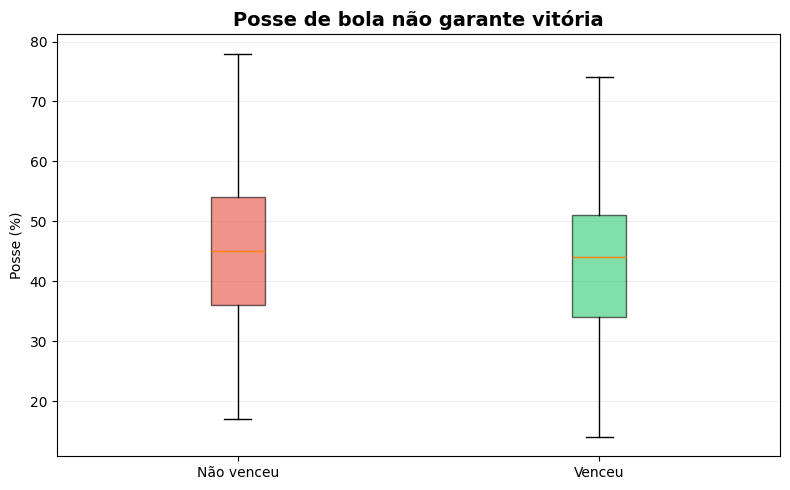

In [40]:
plt.figure(figsize=(8, 5))

box = plt.boxplot(
    [df_final[df_final['win'] == 0]['possession'],
     df_final[df_final['win'] == 1]['possession']],
    labels=['Não venceu', 'Venceu'],
    patch_artist=True
)

cores = ['#E74C3C', '#2ECC71']
for patch, cor in zip(box['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.6)

plt.title('Posse de bola não garante vitória', fontsize=14, weight='bold')
plt.ylabel('Posse (%)')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### 8.2 Eficiência ofensiva por resultado

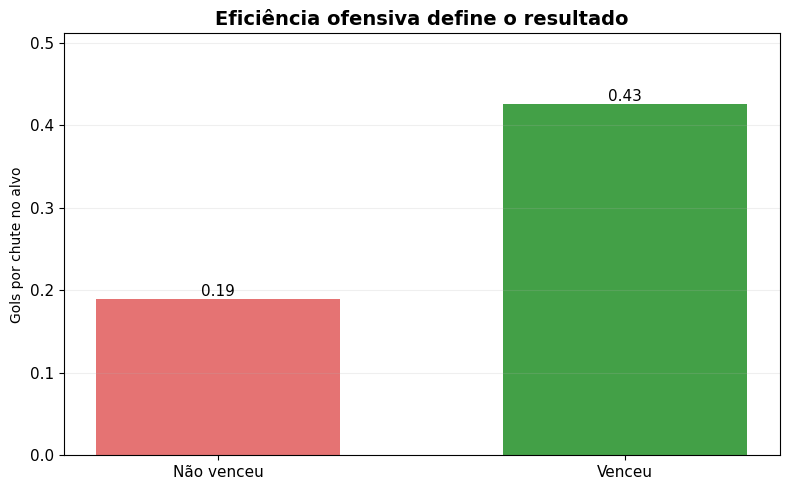

In [41]:
aplicar_estilo_padrao()

medias = df_final.groupby('win')['efficiency'].mean()

bars = plt.bar(
    ['Não venceu', 'Venceu'],
    medias,
    color=['#E57373', '#43A047'],
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, height,
        f'{height:.2f}', ha='center', va='bottom', fontsize=11
    )

plt.title('Eficiência ofensiva define o resultado', fontsize=14, weight='bold')
plt.ylabel('Gols por chute no alvo')
plt.ylim(0, max(medias) * 1.2)
plt.tight_layout()
plt.show()

### 8.3 Construção de jogadas por resultado

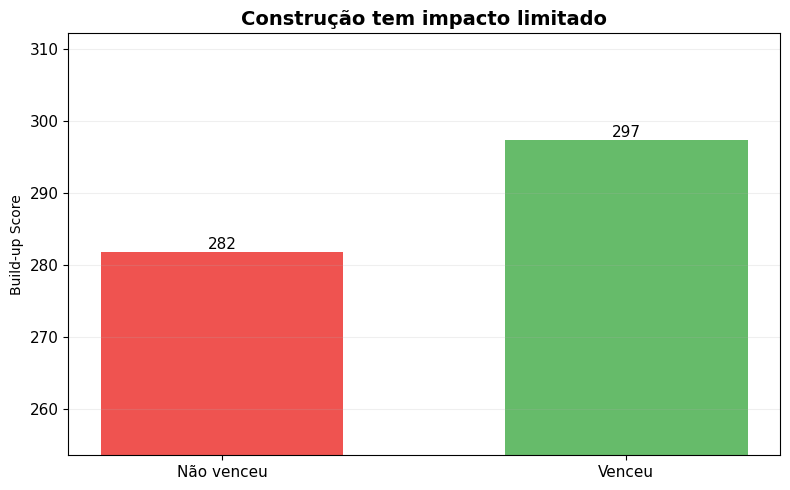

In [42]:
aplicar_estilo_padrao()

medias = df_final.groupby('win')['build_up_score'].mean()

bars = plt.bar(
    ['Não venceu', 'Venceu'],
    medias,
    color=['#EF5350', '#66BB6A'],
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, height,
        f'{height:.0f}', ha='center', va='bottom', fontsize=11
    )

plt.title('Construção tem impacto limitado', fontsize=14, weight='bold')
plt.ylabel('Build-up Score')
plt.ylim(min(medias) * 0.9, max(medias) * 1.05)
plt.tight_layout()
plt.show()

### 8.4 Relação entre eficiência e gols

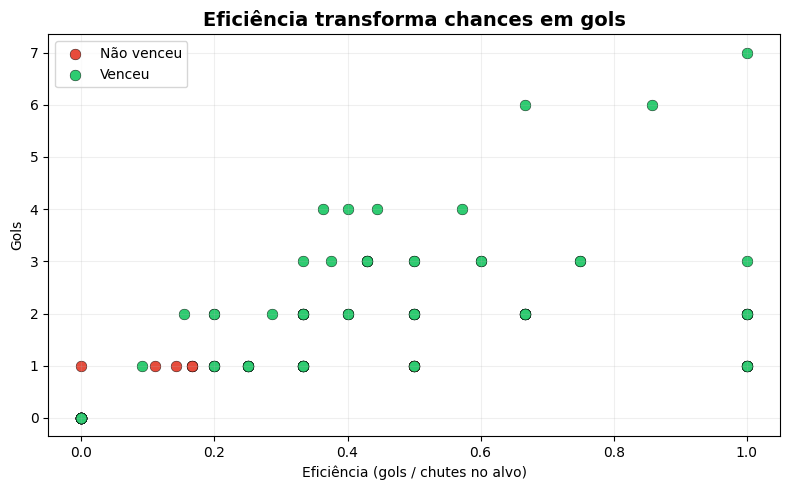

In [43]:
plt.figure(figsize=(8, 5))

cor_perdeu = '#E74C3C'
cor_ganhou = '#2ECC71'

df_win = df_final[df_final['win'] == 1]
df_lose = df_final[df_final['win'] == 0]

plt.scatter(
    df_lose['efficiency'], df_lose['goals'],
    color=cor_perdeu, s=60, edgecolors='black',
    linewidth=0.3, label='Não venceu'
)
plt.scatter(
    df_win['efficiency'], df_win['goals'],
    color=cor_ganhou, s=60, edgecolors='black',
    linewidth=0.3, label='Venceu'
)

plt.xlabel('Eficiência (gols / chutes no alvo)')
plt.ylabel('Gols')
plt.title('Eficiência transforma chances em gols', fontsize=14, weight='bold')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 8.5 Matriz de correlação entre métricas e vitória

Análise das correlações de Spearman entre as três dimensões e a variável
binária `win`. Spearman é preferível a Pearson aqui porque não exige
linearidade e é robusto a outliers.

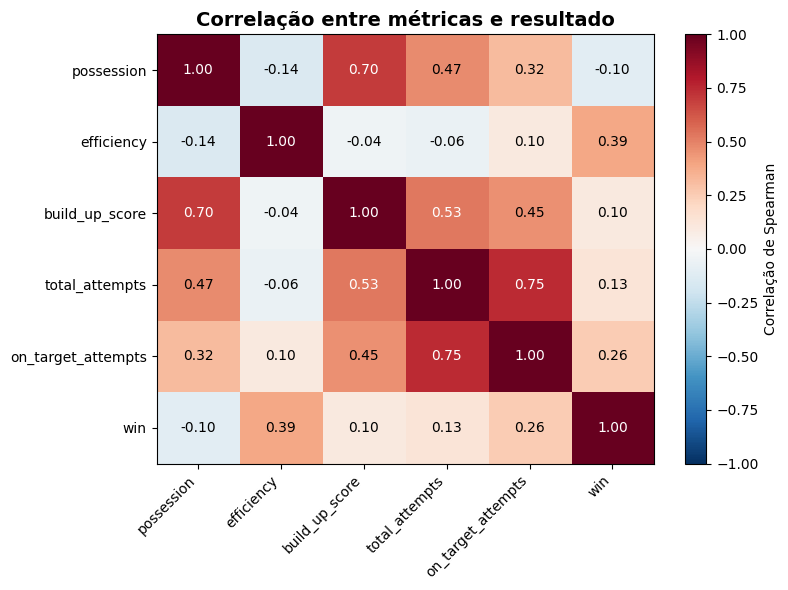

In [44]:
metricas_corr = ['possession', 'efficiency', 'build_up_score',
                 'total_attempts', 'on_target_attempts', 'win']
matriz_corr = df_final[metricas_corr].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matriz_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(metricas_corr)))
ax.set_yticks(range(len(metricas_corr)))
ax.set_xticklabels(metricas_corr, rotation=45, ha='right')
ax.set_yticklabels(metricas_corr)

# Anotar valores na matriz
for r in range(len(metricas_corr)):
    for c in range(len(metricas_corr)):
        valor = matriz_corr.values[r, c]
        cor_texto = 'white' if abs(valor) > 0.5 else 'black'
        ax.text(c, r, f'{valor:.2f}', ha='center', va='center',
                color=cor_texto, fontsize=10)

plt.colorbar(im, ax=ax, label='Correlação de Spearman')
plt.title('Correlação entre métricas e resultado', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 9. Modelagem inferencial — Regressão logística

A análise descritiva mostra diferenças entre grupos, mas não quantifica o
**efeito ajustado** de cada variável quando todas competem simultaneamente
por explicar o resultado. A regressão logística entrega coeficientes
interpretáveis e p-valores condicionados.

As features são padronizadas (z-score) antes do ajuste, de modo que os
coeficientes possam ser comparados em magnitude. A exponencial do
coeficiente fornece o **odds ratio** — razão de chance de vitória associada
a um aumento de um desvio-padrão na variável.

In [45]:
features = ['possession', 'efficiency', 'build_up_score']
X = df_final[features].copy()
y = df_final['win']

# Padronização
X_padronizado = (X - X.mean()) / X.std()
X_padronizado = sm.add_constant(X_padronizado)

modelo = sm.Logit(y, X_padronizado).fit(disp=False)

# Tabela com coeficientes, p-valor e odds ratio
resumo_modelo = pd.DataFrame({
    'coeficiente': modelo.params,
    'p_valor': modelo.pvalues,
    'odds_ratio': np.exp(modelo.params),
    'IC_95_inf': np.exp(modelo.conf_int()[0]),
    'IC_95_sup': np.exp(modelo.conf_int()[1]),
}).round(4)

print(f'Pseudo R² (McFadden): {modelo.prsquared:.3f}')
print(f'Log-likelihood: {modelo.llf:.2f}')
print()
resumo_modelo

Pseudo R² (McFadden): 0.162
Log-likelihood: -71.41



,coeficiente,p_valor,odds_ratio,IC_95_inf,IC_95_sup
const,0.6086,0.0038,1.8379,1.2175,2.7743
possession,-0.7611,0.0181,0.4672,0.2485,0.8780
efficiency,0.8845,0.0003,2.4218,1.5072,3.8914
build_up_score,0.9396,0.0066,2.5591,1.2990,5.0415


**Leitura do modelo:** o odds ratio indica o efeito multiplicativo sobre a
chance de vitória. Um valor de 2,0 significa que a chance de vitória dobra
para cada desvio-padrão de aumento na variável; valores próximos de 1,0
indicam efeito nulo. O intervalo de confiança 95% que cruza 1,0 indica
ausência de efeito estatisticamente detectável.

A magnitude relativa dos coeficientes padronizados permite ranquear as
três dimensões pela força com que cada uma prediz vitória.

## 10. Exportação do dataset tratado. O DataFrame final é persistido em `data/processed/` para reutilização emanálises futuras ou alimentação de modelos preditivos sem necessidade dereexecutar o pipeline de transformação.

In [46]:
df_final.to_csv('data/processed/world_cup_2022_cleaned.csv', index=False)

## 11. Limitações da análise

A interpretação dos resultados deve considerar as seguintes limitações:

1. **Tamanho amostral reduzido.** A Copa do Mundo 2022 contém 64 partidas
   (128 observações time-jogo). Conclusões devem ser tratadas como
   evidência preliminar, não como leis gerais sobre futebol.
2. **Generalização restrita.** Torneios curtos com formato eliminatório
   têm dinâmica distinta de ligas regulares — equipes podem adotar
   posturas mais conservadoras, e a amostra de adversários é enviesada
   para seleções nacionais. Os resultados não devem ser extrapolados
   para futebol de clubes ou ligas longas sem validação adicional.
3. **Empate equiparado a derrota na variável `win`.** A variável binária
   é simplificadora; a variável `match_result` (W/D/L) preserva a
   informação completa e pode ser usada em análises mais granulares.
4. **Métricas não capturam contexto.** Posse, eficiência e build-up são
   indicadores agregados — não distinguem posse defensiva de posse
   dominante, nem chutes em situação de pressão de chutes em contra-ataque.
5. **Causalidade não estabelecida.** A análise mostra associação, não
   relação causal. Eficiência e vitória podem ter um determinante comum
   (qualidade do plantel, por exemplo) que não foi controlado.

## 12. Conclusão

A combinação de análise descritiva, testes não paramétricos e regressão
logística produz um diagnóstico mais nuançado do que cada técnica
isoladamente entregaria.

**Eficiência ofensiva** é a variável mais robusta. A diferença entre
vencedores (0,43 gols por chute no alvo) e não vencedores (0,19) é
estatisticamente significante (Mann-Whitney p < 0,001) com tamanho de
efeito moderado-grande. A regressão confirma o achado: a chance de
vitória mais que dobra a cada desvio-padrão de aumento na eficiência
(odds ratio ≈ 2,42).

**Posse de bola** apresenta o resultado mais contraintuitivo. Na análise
univariada, a diferença média entre os grupos é pequena e não significante.
Na análise multivariada, contudo, posse aparece com **coeficiente negativo
e significante** (p ≈ 0,02; odds ratio ≈ 0,47): controlando por eficiência
e construção, equipes com maior posse têm *menor* chance de vencer. A
leitura mais provável é que posse, em torneios eliminatórios, está
associada a equipes que precisam atacar frequentemente as que estão
em desvantagem ou enfrentam adversários superiores.

**Construção de jogadas** ilustra o ganho da análise multivariada.
Descritivamente, a diferença entre grupos é pequena e não significante.
No modelo logístico, ajustada pelas outras dimensões, a variável aparece
com o coeficiente de maior magnitude (odds ratio ≈ 2,56; p ≈ 0,007),
sugerindo que progressão ofensiva eficaz é um fator subestimado na
análise univariada e relevante quando isolada do efeito de posse.

O **pseudo R² de McFadden ≈ 0,16** indica ajuste satisfatório dado o
caráter multifatorial do resultado de uma partida fatores não modelados aqui (qualidade individual, condição física, contexto tático) explicam a maior parte da variância restante.

A conclusão final inverte a narrativa popular: dominar a posse de bola
não apenas não garante vitória em contexto multivariado, está
associada a desvantagem. O que diferencia vencedores é a combinação
entre **eficiência na finalização** e **eficácia na construção**.